# 4B - Que variaveis do Pacifico mais determinam cada fase do ciclo ENSO?

**Pergunta especifica.** Estudo puramente estatistico: entre as variaveis do conjunto Pacifico (SSTA, D20, OHC 0-300/0-700, SSH, tilt, WWV, tau_x), quais mais determinam a **I. Genese**, o **II. Crescimento**, o **III. Pico** e o **IV. Decaimento** - para El Nino e para La Nina?

**Metodologia.** Tres testes complementares, todos nao parametricos e sem ML: (1) **separacao fase vs neutro** - Mann-Whitney U da variavel (z-score) em cada fase contra as semanas neutras, com tamanho de efeito delta de Cliff e FDR BH por tipo de sinal; (2) **discriminancia entre fases** - Kruskal-Wallis sobre as 4 fases dentro de cada tipo, com epsilon-quadrado (quais variaveis mais "sabem" em que fase o ciclo esta); (3) **determinacao da intensidade** - Spearman entre o estado medio da variavel na genese/crescimento de cada evento e o |ONI| do pico (quais variaveis na fase inicial determinam o tamanho do pico).

**Saidas.** `phase4B_determinantes_fases.csv`, `phase4B_discriminancia_fases.csv`, `phase4B_fase_intensidade_pico.csv`, `phase4B_heatmap_determinantes.png`, `phase4B_ranking_discriminancia.png`.

In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal, spearmanr
import fase4_utils as u

w = u.load_pacific_weekly()
z = (w - w.mean()) / w.std()
fases = pd.read_csv(u.STATS/'phase4A_fases_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev = pd.read_csv(u.STATS/'phase4A_eventos_enso.csv', parse_dates=['onset','pico','fim'])
fases = fases.reindex(z.index).fillna({'fase':'neutro','tipo':'neutro','event_id':''})
m_neutro = fases['fase'].eq('neutro')
print('semanas neutras:', int(m_neutro.sum()), '| matriz', z.shape)

semanas neutras: 717 | matriz (2372, 8)


In [2]:
# (1) separacao fase vs neutro: mediana z, delta de Cliff e p (Mann-Whitney) com FDR por tipo
rows = []
for tipo in ['el_nino','la_nina']:
    for fase in u.FASE_ORDER:
        m = fases['tipo'].eq(tipo) & fases['fase'].eq(fase)
        for v in u.PACIFIC_VARS:
            a = z.loc[m, v].dropna(); b = z.loc[m_neutro, v].dropna()
            if len(a) < 20:
                continue
            U, p = mannwhitneyu(a, b, alternative='two-sided')
            cliff = 2.0*U/(len(a)*len(b)) - 1.0
            rows.append({'tipo': tipo, 'fase': fase, 'variavel': v, 'rotulo': u.var_label(v),
                         'n_semanas': int(len(a)), 'mediana_z': round(float(a.median()),3),
                         'cliffs_delta': round(float(cliff),3), 'p_bruto': float(p)})
det = pd.DataFrame(rows)
for tipo in ['el_nino','la_nina']:
    m = det['tipo'].eq(tipo)
    det.loc[m, 'sig_fdr'] = u.fdr_bh(det.loc[m, 'p_bruto'].to_numpy(), alpha=0.10)
det['p_bruto'] = det['p_bruto'].round(5)
u.save_table(det, 'phase4B_determinantes_fases.csv', index=False)

# (2) discriminancia entre as 4 fases (dentro de cada tipo): Kruskal-Wallis + epsilon^2
rows = []
for tipo in ['el_nino','la_nina']:
    for v in u.PACIFIC_VARS:
        grupos = [z.loc[fases['tipo'].eq(tipo) & fases['fase'].eq(f), v].dropna() for f in u.FASE_ORDER]
        grupos = [g for g in grupos if len(g) >= 10]
        if len(grupos) < 3:
            continue
        H, p = kruskal(*grupos)
        n = sum(len(g) for g in grupos); k = len(grupos)
        eps2 = max((H - k + 1) / (n - k), 0.0)
        rows.append({'tipo': tipo, 'variavel': v, 'rotulo': u.var_label(v), 'H_kruskal': round(float(H),1),
                     'p_bruto': round(float(p),6), 'epsilon2': round(float(eps2),3), 'n_semanas': int(n)})
disc = pd.DataFrame(rows).sort_values(['tipo','epsilon2'], ascending=[True, False])
u.save_table(disc, 'phase4B_discriminancia_fases.csv', index=False)
print(disc.to_string(index=False))

[tabela] data/processed/parquet/statistics/phase4B_determinantes_fases.csv


[tabela] data/processed/parquet/statistics/phase4B_discriminancia_fases.csv
   tipo             variavel      rotulo  H_kruskal  p_bruto  epsilon2  n_semanas
el_nino          nino34_ssta        SSTA      533.1 0.000000     0.649        821
el_nino               tilt_m        Tilt      419.2 0.000000     0.509        821
el_nino            ohc_0_300    OHC0-300      413.8 0.000000     0.503        821
el_nino                ssh_m         SSH      403.6 0.000000     0.490        821
el_nino            ohc_0_700    OHC0-700      389.4 0.000000     0.473        821
el_nino                d20_m         D20      325.0 0.000000     0.394        821
el_nino                  wwv         WWV      201.6 0.000000     0.243        821
el_nino tau_x_anom_nino34_pa tau_x anom.      123.4 0.000000     0.147        821
la_nina          nino34_ssta        SSTA      436.9 0.000000     0.523        834
la_nina                d20_m         D20      207.1 0.000000     0.246        834
la_nina               

In [3]:
# (3) o estado na genese/crescimento determina o tamanho do pico?
rows = []
for tipo in ['el_nino','la_nina']:
    sub = ev[ev.tipo == tipo]
    for fase in ['genese','crescimento']:
        for v in u.PACIFIC_VARS:
            vals, alvo = [], []
            for _, e in sub.iterrows():
                m = fases['event_id'].eq(e.event_id) & fases['fase'].eq(fase)
                s = z.loc[m, v].mean()
                if np.isfinite(s):
                    vals.append(float(s)); alvo.append(abs(float(e.oni_pico_c)))
            if len(vals) < 5:
                continue
            rho, p = spearmanr(vals, alvo)
            rows.append({'tipo': tipo, 'fase_precursora': fase, 'variavel': v, 'rotulo': u.var_label(v),
                         'n_eventos': len(vals), 'spearman_rho': round(float(rho),3), 'p_bruto': round(float(p),4)})
inten = pd.DataFrame(rows).sort_values(['tipo','fase_precursora','spearman_rho'], key=lambda s: s.map(abs) if s.name=='spearman_rho' else s, ascending=[True,True,False])
u.save_table(inten, 'phase4B_fase_intensidade_pico.csv', index=False)
print(inten.to_string(index=False))

[tabela] data/processed/parquet/statistics/phase4B_fase_intensidade_pico.csv
   tipo fase_precursora             variavel      rotulo  n_eventos  spearman_rho  p_bruto
el_nino     crescimento          nino34_ssta        SSTA         11         0.727   0.0112
el_nino     crescimento                ssh_m         SSH         11         0.382   0.2466
el_nino     crescimento tau_x_anom_nino34_pa tau_x anom.         11         0.291   0.3855
el_nino     crescimento            ohc_0_300    OHC0-300         11         0.155   0.6500
el_nino     crescimento               tilt_m        Tilt         11         0.118   0.7293
el_nino     crescimento            ohc_0_700    OHC0-700         11         0.109   0.7495
el_nino     crescimento                d20_m         D20         11        -0.055   0.8734
el_nino     crescimento                  wwv         WWV         11         0.055   0.8734
el_nino          genese                d20_m         D20         12         0.510   0.0899
el_nino      

[figura] data/processed/figures/fase4/phase4B_heatmap_determinantes.png


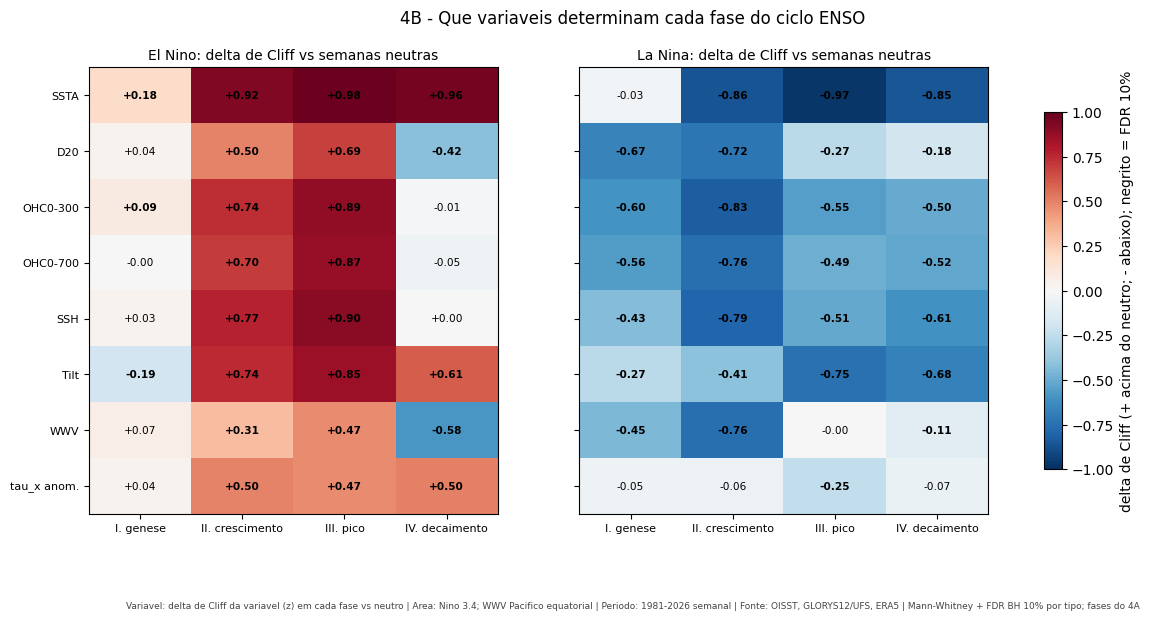

[figura] data/processed/figures/fase4/phase4B_ranking_discriminancia.png


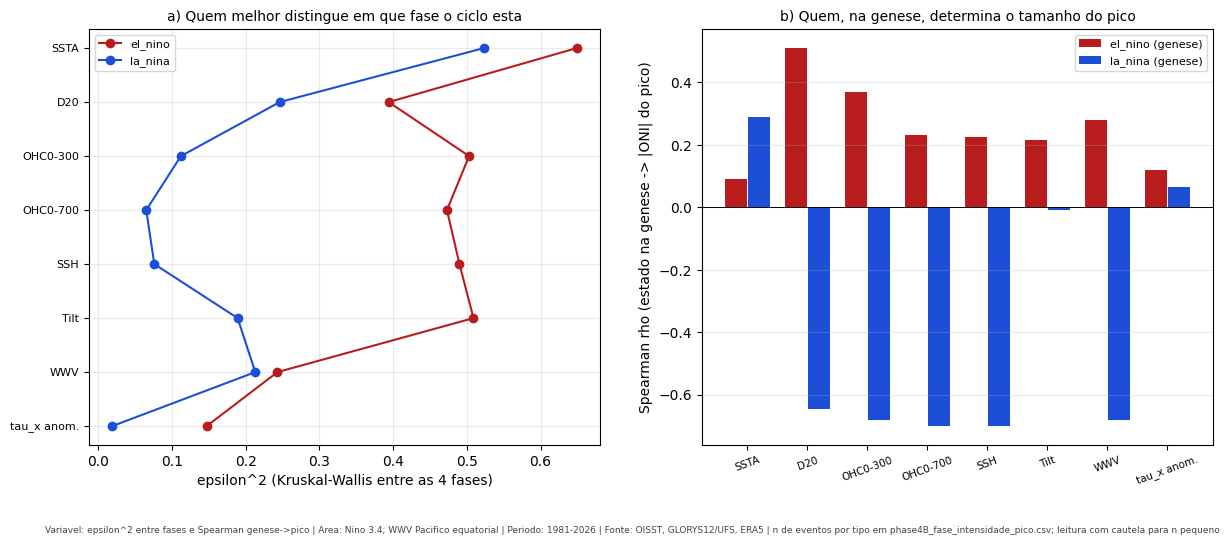

In [4]:
# Figura 1: heatmap dos determinantes (delta de Cliff) fase x variavel, EN e LN
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.8), sharey=True)
for ax, tipo, tit in [(axes[0],'el_nino','El Nino'), (axes[1],'la_nina','La Nina')]:
    pv = det[det.tipo==tipo].pivot(index='rotulo', columns='fase', values='cliffs_delta')
    pv = pv.reindex(index=[u.var_label(v) for v in u.PACIFIC_VARS], columns=u.FASE_ORDER)
    sig = det[det.tipo==tipo].pivot(index='rotulo', columns='fase', values='sig_fdr')
    sig = sig.reindex(index=pv.index, columns=pv.columns)
    im = ax.imshow(pv.values.astype(float), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(pv.columns))); ax.set_xticklabels(['I. '+pv.columns[0],'II. '+pv.columns[1],'III. '+pv.columns[2],'IV. '+pv.columns[3]], fontsize=8)
    ax.set_yticks(range(len(pv.index))); ax.set_yticklabels(pv.index, fontsize=8)
    for i in range(pv.shape[0]):
        for j in range(pv.shape[1]):
            val = pv.values[i, j]
            if np.isfinite(val):
                peso = 'bold' if bool(sig.values[i, j]) else 'normal'
                ax.text(j, i, f'{val:+.2f}', ha='center', va='center', fontsize=7.6, weight=peso)
    ax.set_title(f'{tit}: delta de Cliff vs semanas neutras', fontsize=10)
fig.colorbar(im, ax=axes, shrink=.8, label='delta de Cliff (+ acima do neutro; - abaixo); negrito = FDR 10%')
fig.suptitle('4B - Que variaveis determinam cada fase do ciclo ENSO')
u.stamp_caption(fig, variavel='delta de Cliff da variavel (z) em cada fase vs neutro', area='Nino 3.4; WWV Pacifico equatorial', periodo='1981-2026 semanal', fonte='OISST, GLORYS12/UFS, ERA5', extra='Mann-Whitney + FDR BH 10% por tipo; fases do 4A')
u.save_fig(fig, 'phase4B_heatmap_determinantes.png')
plt.show()

# Figura 2: ranking de discriminancia entre fases + determinantes da intensidade do pico
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.4))
for tipo, cor in [('el_nino','#b91c1c'), ('la_nina','#1d4ed8')]:
    sub = disc[disc.tipo==tipo].set_index('rotulo').reindex([u.var_label(v) for v in u.PACIFIC_VARS])
    axes[0].plot(sub['epsilon2'].values, range(len(sub)), 'o-', color=cor, label=tipo)
axes[0].set_yticks(range(len(u.PACIFIC_VARS))); axes[0].set_yticklabels([u.var_label(v) for v in u.PACIFIC_VARS], fontsize=8)
axes[0].invert_yaxis(); axes[0].set_xlabel('epsilon^2 (Kruskal-Wallis entre as 4 fases)')
axes[0].set_title('a) Quem melhor distingue em que fase o ciclo esta', fontsize=10)
axes[0].legend(fontsize=8); axes[0].grid(alpha=.25)
xx = np.arange(len(u.PACIFIC_VARS))
for k, (tipo, cor) in enumerate([('el_nino','#b91c1c'), ('la_nina','#1d4ed8')]):
    sub = inten[(inten.tipo==tipo) & (inten.fase_precursora=='genese')].set_index('variavel').reindex(u.PACIFIC_VARS)
    axes[1].bar(xx + (k-.5)*.38, sub['spearman_rho'].values, width=.36, color=cor, label=f'{tipo} (genese)')
axes[1].axhline(0, color='k', lw=.7)
axes[1].set_xticks(xx); axes[1].set_xticklabels([u.var_label(v) for v in u.PACIFIC_VARS], fontsize=7.5, rotation=20)
axes[1].set_ylabel('Spearman rho (estado na genese -> |ONI| do pico)')
axes[1].set_title('b) Quem, na genese, determina o tamanho do pico', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(axis='y', alpha=.25)
u.stamp_caption(fig, variavel='epsilon^2 entre fases e Spearman genese->pico', area='Nino 3.4; WWV Pacifico equatorial', periodo='1981-2026', fonte='OISST, GLORYS12/UFS, ERA5', extra='n de eventos por tipo em phase4B_fase_intensidade_pico.csv; leitura com cautela para n pequeno')
u.save_fig(fig, 'phase4B_ranking_discriminancia.png')
plt.show()

In [5]:
# (4) RELACOES ENTRE VARIAVEIS: dentre TODAS as duplas, qual relacao melhor determina a fase?
# Para cada par testamos tres formas de relacao por semana e medimos o quanto ela separa as 4 fases.
from itertools import combinations
from scipy.stats import kruskal
PAIRS = list(combinations(u.PACIFIC_VARS, 2))
WIN = 13  # janela movel ~3 meses para correlacao/volatilidade locais

def _eps2(groups):
    groups = [g.dropna() for g in groups if g.notna().sum() >= 10]
    if len(groups) < 3:
        return np.nan, np.nan
    H, p = kruskal(*groups)
    n = sum(len(g) for g in groups); k = len(groups)
    return max((H - k + 1) / (n - k), 0.0), p

rows = []
for tipo in ['el_nino','la_nina']:
    m_tipo = fases['tipo'].eq(tipo)
    for a, b in PAIRS:
        rcorr = z[a].rolling(WIN, center=True, min_periods=8).corr(z[b])          # co-variacao local
        comov = z[a] * z[b]                                                        # co-movimento instantaneo
        volrat = np.log(z[a].rolling(WIN, center=True, min_periods=8).std() /
                        z[b].rolling(WIN, center=True, min_periods=8).std())       # volatilidade de um sobre o outro
        for nome, serie in [('corr_movel', rcorr), ('co_movimento', comov), ('log_razao_volatilidade', volrat)]:
            e2, p = _eps2([serie[m_tipo & fases['fase'].eq(f)] for f in u.FASE_ORDER])
            rows.append({'tipo': tipo, 'par': f'{u.var_label(a)}~{u.var_label(b)}', 'var_a': a, 'var_b': b,
                         'relacao': nome, 'epsilon2': round(e2,3) if np.isfinite(e2) else np.nan,
                         'p_bruto': p})
rel = pd.DataFrame(rows)
for tipo in ['el_nino','la_nina']:
    m = rel['tipo'].eq(tipo) & rel['epsilon2'].notna()
    rel.loc[m, 'sig_fdr'] = u.fdr_bh(rel.loc[m, 'p_bruto'].to_numpy(), alpha=0.10)
rel['p_bruto'] = rel['p_bruto'].round(6)
rel = rel.sort_values(['tipo','epsilon2'], ascending=[True, False])
u.save_table(rel, 'phase4B_relacoes_pares_fases.csv', index=False)
print('TOP relacoes que determinam a fase (El Nino):')
print(rel[rel.tipo=='el_nino'].head(8)[['par','relacao','epsilon2','p_bruto']].to_string(index=False))
print('\nTOP relacoes que determinam a fase (La Nina):')
print(rel[rel.tipo=='la_nina'].head(8)[['par','relacao','epsilon2','p_bruto']].to_string(index=False))

[tabela] data/processed/parquet/statistics/phase4B_relacoes_pares_fases.csv
TOP relacoes que determinam a fase (El Nino):
              par      relacao  epsilon2  p_bruto
    SSTA~OHC0-300 co_movimento     0.543      0.0
         SSTA~SSH co_movimento     0.515      0.0
    SSTA~OHC0-700 co_movimento     0.504      0.0
         SSTA~D20 co_movimento     0.494      0.0
     OHC0-300~SSH co_movimento     0.438      0.0
        SSTA~Tilt co_movimento     0.426      0.0
     OHC0-700~SSH co_movimento     0.407      0.0
OHC0-300~OHC0-700 co_movimento     0.404      0.0

TOP relacoes que determinam a fase (La Nina):
          par      relacao  epsilon2  p_bruto
    SSTA~Tilt co_movimento     0.332      0.0
SSTA~OHC0-300 co_movimento     0.249      0.0
     SSTA~SSH co_movimento     0.209      0.0
      D20~WWV co_movimento     0.203      0.0
 OHC0-300~WWV co_movimento     0.197      0.0
     SSTA~WWV co_movimento     0.193      0.0
SSTA~OHC0-700 co_movimento     0.192      0.0
 OHC0-700~WWV

[figura] data/processed/figures/fase4/phase4B_relacoes_pares.png


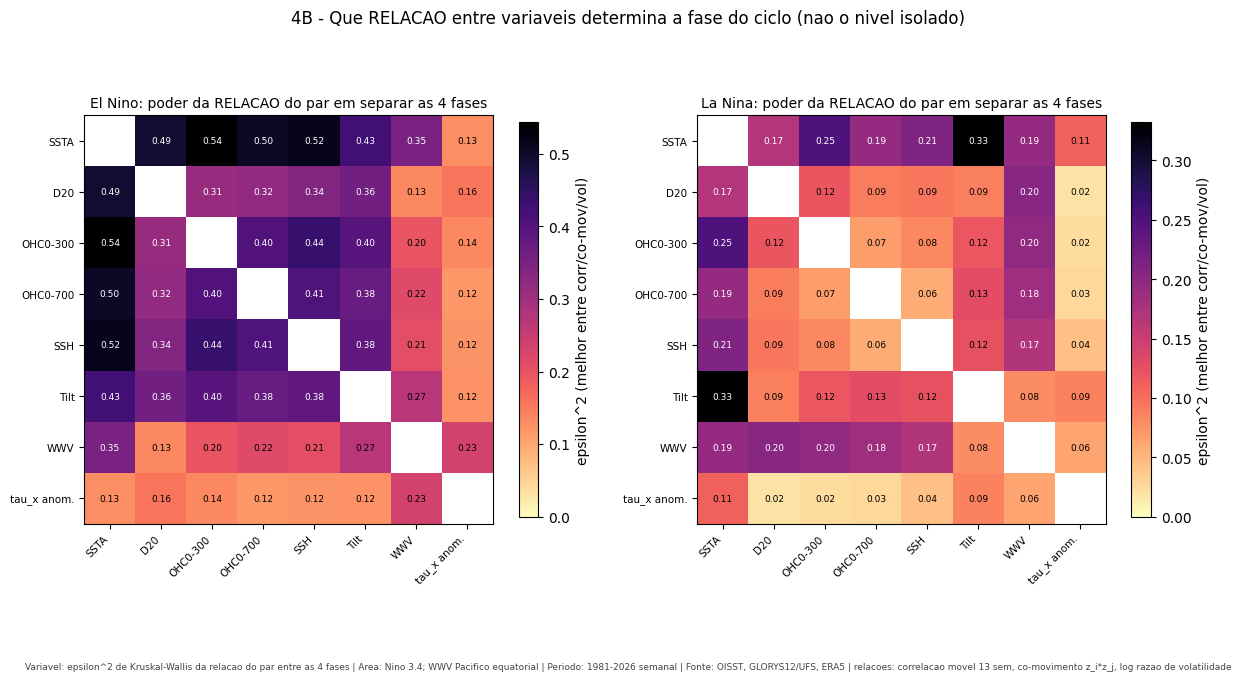

In [6]:
# Figura: matriz de discriminancia por par (melhor relacao entre as 3 testadas), EN e LN
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4))
labels = [u.var_label(v) for v in u.PACIFIC_VARS]
for ax, tipo, tit in [(axes[0],'el_nino','El Nino'), (axes[1],'la_nina','La Nina')]:
    M = np.full((len(u.PACIFIC_VARS), len(u.PACIFIC_VARS)), np.nan)
    best = rel[rel.tipo==tipo].groupby(['var_a','var_b'])['epsilon2'].max()
    for (a, b), e2 in best.items():
        i, j = u.PACIFIC_VARS.index(a), u.PACIFIC_VARS.index(b)
        M[i, j] = e2; M[j, i] = e2
    im = ax.imshow(M, cmap='magma_r', vmin=0, vmax=np.nanmax(M) if np.isfinite(np.nanmax(M)) else 1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7.5)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7.5)
    for i in range(len(labels)):
        for j in range(len(labels)):
            if np.isfinite(M[i, j]):
                ax.text(j, i, f'{M[i,j]:.2f}', ha='center', va='center', fontsize=6.5,
                        color='white' if M[i,j] > 0.5*np.nanmax(M) else 'black')
    ax.set_title(f'{tit}: poder da RELACAO do par em separar as 4 fases', fontsize=10)
    fig.colorbar(im, ax=ax, shrink=.8, label='epsilon^2 (melhor entre corr/co-mov/vol)')
fig.suptitle('4B - Que RELACAO entre variaveis determina a fase do ciclo (nao o nivel isolado)')
u.stamp_caption(fig, variavel='epsilon^2 de Kruskal-Wallis da relacao do par entre as 4 fases', area='Nino 3.4; WWV Pacifico equatorial', periodo='1981-2026 semanal', fonte='OISST, GLORYS12/UFS, ERA5', extra='relacoes: correlacao movel 13 sem, co-movimento z_i*z_j, log razao de volatilidade')
u.save_fig(fig, 'phase4B_relacoes_pares.png')
plt.show()

[tabela] data/processed/parquet/statistics/phase4B_estrutura_correlacao_distancias.csv
[tabela] data/processed/parquet/statistics/phase4B_matriz_correlacao_por_fase.csv
Distancia entre estruturas de correlacao (quanto maior, mais a relacao muda entre fases):
   tipo      fase_1      fase_2  dist_frobenius_norm
el_nino      genese crescimento                0.183
el_nino      genese        pico                0.188
el_nino      genese  decaimento                0.173
el_nino crescimento        pico                0.145
el_nino crescimento  decaimento                0.208
el_nino        pico  decaimento                0.194
la_nina      genese crescimento                0.112
la_nina      genese        pico                0.199
la_nina      genese  decaimento                0.254
la_nina crescimento        pico                0.125
la_nina crescimento  decaimento                0.248
la_nina        pico  decaimento                0.216


[figura] data/processed/figures/fase4/phase4B_estrutura_correlacao.png


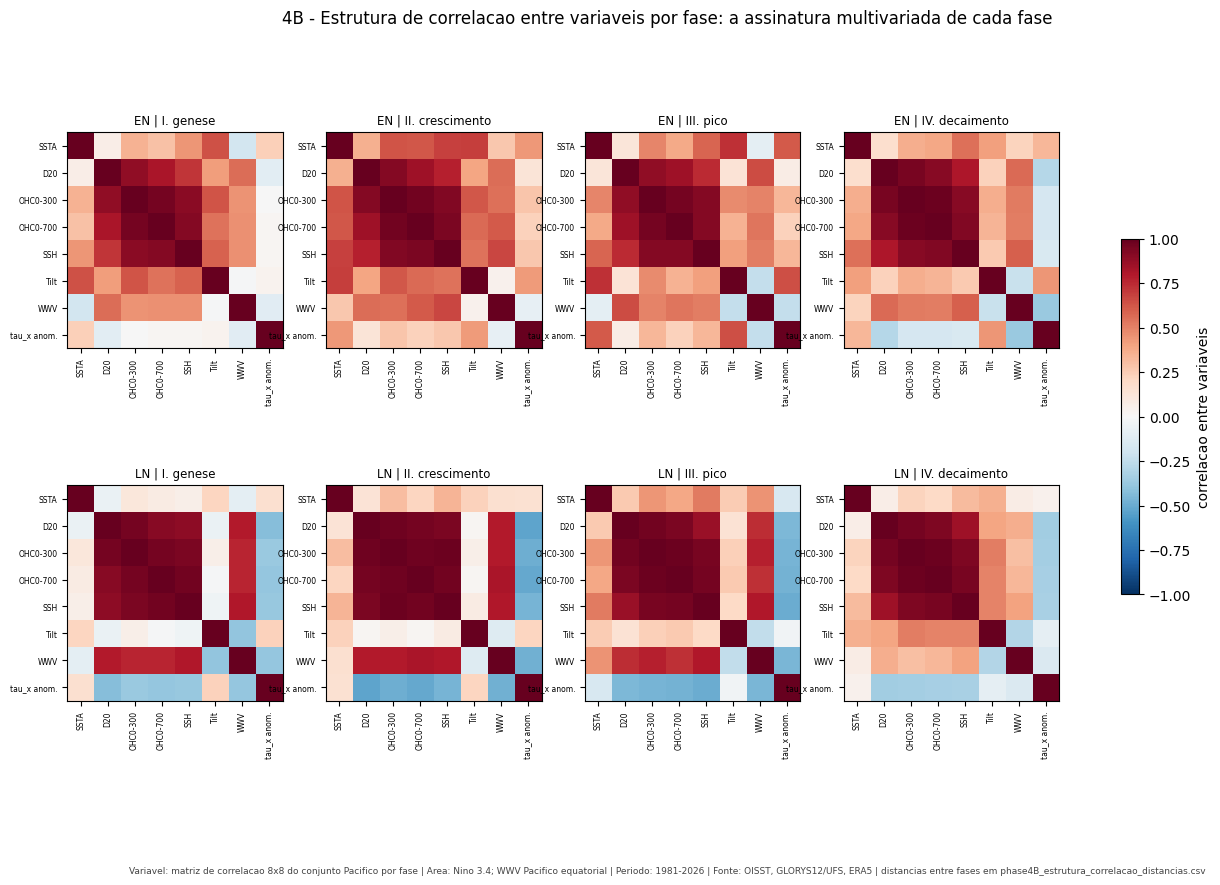

In [7]:
# (5) CORRELACOES COMPLEXAS: a ESTRUTURA de correlacao muda de fase para fase?
# Matriz de correlacao 8x8 por fase e distancia de Frobenius entre fases (assinatura multivariada).
import itertools
mats = {}
rows = []
for tipo in ['el_nino','la_nina']:
    for f in u.FASE_ORDER:
        sub = z[fases['tipo'].eq(tipo) & fases['fase'].eq(f)][u.PACIFIC_VARS].dropna()
        mats[(tipo, f)] = sub.corr() if len(sub) >= 15 else None
    for f1, f2 in itertools.combinations(u.FASE_ORDER, 2):
        A, B = mats.get((tipo, f1)), mats.get((tipo, f2))
        if A is None or B is None:
            continue
        dist = float(np.sqrt(np.nansum((A.values - B.values)**2)) / A.shape[0])
        rows.append({'tipo': tipo, 'fase_1': f1, 'fase_2': f2, 'dist_frobenius_norm': round(dist,3)})
dist_tab = pd.DataFrame(rows)
u.save_table(dist_tab, 'phase4B_estrutura_correlacao_distancias.csv', index=False)
corr_long = pd.concat({f'{t}|{f}': m for (t, f), m in mats.items() if m is not None},
                      names=['tipo_fase','variavel'])
u.save_table(corr_long, 'phase4B_matriz_correlacao_por_fase.csv')
print('Distancia entre estruturas de correlacao (quanto maior, mais a relacao muda entre fases):')
print(dist_tab.to_string(index=False))

fig, axes = plt.subplots(2, 4, figsize=(16, 8.4))
for r, tipo in enumerate(['el_nino','la_nina']):
    for c, f in enumerate(u.FASE_ORDER):
        ax = axes[r, c]; M = mats.get((tipo, f))
        if M is None:
            ax.axis('off'); ax.set_title(f'{tipo} | {f}\n(sem amostra)', fontsize=8); continue
        im = ax.imshow(M.values, cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(len(u.PACIFIC_VARS))); ax.set_yticks(range(len(u.PACIFIC_VARS)))
        ax.set_xticklabels([u.var_label(v) for v in u.PACIFIC_VARS], rotation=90, fontsize=5.5)
        ax.set_yticklabels([u.var_label(v) for v in u.PACIFIC_VARS], fontsize=5.5)
        ax.set_title(f'{"EN" if tipo=="el_nino" else "LN"} | {["I.","II.","III.","IV."][c]} {f}', fontsize=8.5)
fig.colorbar(im, ax=axes, shrink=.55, label='correlacao entre variaveis')
fig.suptitle('4B - Estrutura de correlacao entre variaveis por fase: a assinatura multivariada de cada fase', y=0.98)
u.stamp_caption(fig, variavel='matriz de correlacao 8x8 do conjunto Pacifico por fase', area='Nino 3.4; WWV Pacifico equatorial', periodo='1981-2026', fonte='OISST, GLORYS12/UFS, ERA5', extra='distancias entre fases em phase4B_estrutura_correlacao_distancias.csv')
u.save_fig(fig, 'phase4B_estrutura_correlacao.png')
plt.show()

**Leitura do 4B.** O estudo tem duas camadas. Primeiro, **variaveis isoladas**: quais se afastam do neutro em cada fase (delta de Cliff), quais discriminam a fase (epsilon^2) e quais na genese determinam a intensidade do pico (Spearman). Segundo, **relacoes entre variaveis** (a pergunta central): varrendo todos os 28 pares, mede-se se a *relacao* entre duas variaveis - correlacao movel, co-movimento z_i*z_j ou razao de volatilidade - determina em que fase o ciclo esta. O resultado fisico e nitido: o **co-movimento SSTA<->recarga** (OHC/SSH/D20/tilt) e a relacao que melhor marca a fase no El Nino (assinatura do acoplamento de Bjerknes, maximo no crescimento/pico), enquanto na La Nina destacam-se SSTA<->tilt e D20<->WWV. Por fim, a **estrutura de correlacao completa** (matriz 8x8) muda de forma entre as fases, e a distancia de Frobenius quantifica isso: cada fase tem uma assinatura multivariada propria, nao apenas niveis diferentes.